# SHAP explainers and gradient-boosting trees — Solutions

## What is SHAP?

In Unit 5, CatBoost gave us a single **feature importance score** per feature — useful, but coarse. It tells us *which* features matter on average, not *how* they push a specific prediction up or down.

**SHAP** (SHapley Additive exPlanations) borrows an idea from cooperative game theory. Imagine the features are players, and the "payout" is the model's prediction for one observation. The Shapley value of a feature is its **fair share of the prediction**, averaged over every possible ordering in which features could be added to the model.

This gives us, for every prediction:

$$f(x) = \underbrace{E[f(X)]}_{\text{base value}} + \sum_i \phi_i(x)$$

where each $\phi_i(x)$ is feature $i$'s SHAP value for that row. We'll verify this **additivity property** explicitly below.

Three plots we'll use today:
- **Bar plot** — mean $|\phi_i|$ across the dataset. Global feature importance.
- **Beeswarm (summary) plot** — every row's SHAP value per feature, colored by the feature's value. Shows direction × magnitude × spread.
- **Waterfall plot** — one row's prediction decomposed additively from the base value.

## TreeExplainer vs Explainer

- **`shap.Explainer(model)`** is a dispatcher — it inspects the model and picks an algorithm (TreeSHAP, LinearSHAP, Kernel/Permutation SHAP, etc.).
- **`shap.TreeExplainer(model)`** goes straight to **Tree SHAP**, which computes *exact* Shapley values in polynomial time by walking the tree structure. It's the right choice for tree ensembles (CatBoost, XGBoost, LightGBM, sklearn forests).

**Rule of thumb:** for tree models, go straight to `TreeExplainer`. It's exact *and* fast. Use `shap.Explainer` when the model isn't a tree.

We'll use the Kaggle [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) dataset — 1460 houses in Ames, Iowa with ~80 features, predicting `SalePrice`.

In [1]:
# !pip install --upgrade catboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Compatibility shim: older catboost calls the deprecated DataFrame.iteritems,
# which pandas 2.0+ removed. Re-add it if missing.
if not hasattr(pd.DataFrame, 'iteritems'):
    pd.DataFrame.iteritems = pd.DataFrame.items

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

---
# Part 1: Numerical features only

Start with just the numeric columns — simplest possible setup.

In [2]:
df = pd.read_csv("../Data/train.csv")
numerical_df = df.select_dtypes(include=['number'])
numerical_df.shape

(1460, 38)

**Your turn:** define `X` (all numeric columns except `SalePrice`) and `y` (just `SalePrice`). Then do an 80/20 train/test split with `random_state=42`.

In [3]:
X = numerical_df.drop(columns=['SalePrice'])
y = numerical_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Your turn:** initialize a `CatBoostRegressor` with `iterations=1000`, `learning_rate=0.1`, `depth=6`, `verbose=200`. Fit it on the training set, passing `eval_set=(X_test, y_test)` so you can watch the test loss during training.

In [4]:
catboost_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=6, verbose=200
)
catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 72814.1805349	test: 83102.3985393	best: 83102.3985393 (0)	total: 62.9ms	remaining: 1m 2s
200:	learn: 11319.2532249	test: 28033.8861902	best: 27970.2493210 (196)	total: 230ms	remaining: 913ms
400:	learn: 6397.6156860	test: 27814.6924602	best: 27701.7786296 (316)	total: 394ms	remaining: 588ms
600:	learn: 3943.9948458	test: 27818.3555631	best: 27701.7786296 (316)	total: 559ms	remaining: 371ms
800:	learn: 2534.0943017	test: 27905.2871353	best: 27701.7786296 (316)	total: 726ms	remaining: 180ms
999:	learn: 1651.6656324	test: 27917.5022241	best: 27701.7786296 (316)	total: 881ms	remaining: 0us

bestTest = 27701.77863
bestIteration = 316

Shrink model to first 317 iterations.


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', verbose=200)

**Your turn:** predict on `X_test` and print the Pearson correlation between `y_test` and the predictions.

In [5]:
y_pred = catboost_model.predict(X_test)
print(f"Pearson r: {np.corrcoef(y_test, y_pred)[0, 1]:.4f}")

Pearson r: 0.9513


**Your turn:** use `sns.regplot` to plot predicted vs actual `SalePrice`. Label the axes.

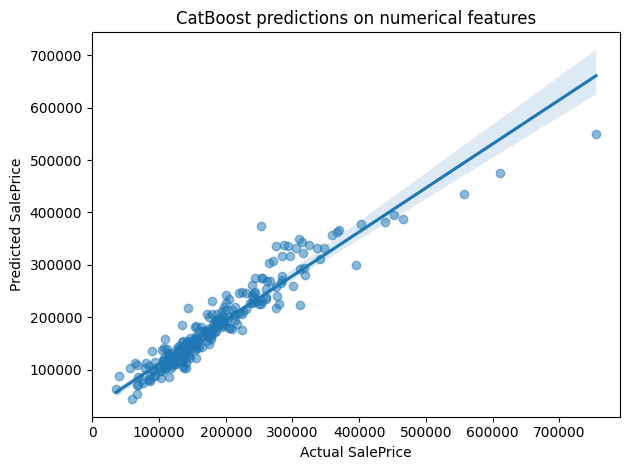

In [6]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.5})
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('CatBoost predictions on numerical features')
plt.tight_layout()

## SHAP on the numerical model

The code below is **demo code** — just run it and focus on interpreting the outputs.

In [6]:
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer(X_test)

print("shap_values shape:", shap_values.values.shape)  # (n_test, n_features)
print("base value (expected prediction):", shap_values.base_values[0])

shap_values shape: (292, 37)
base value (expected prediction): 181444.76034182115


### Bar plot — global importance

Heights = mean $|\phi_i|$ across the test set. This is the SHAP analog of the feature importance you got from CatBoost in Unit 5.

In [9]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


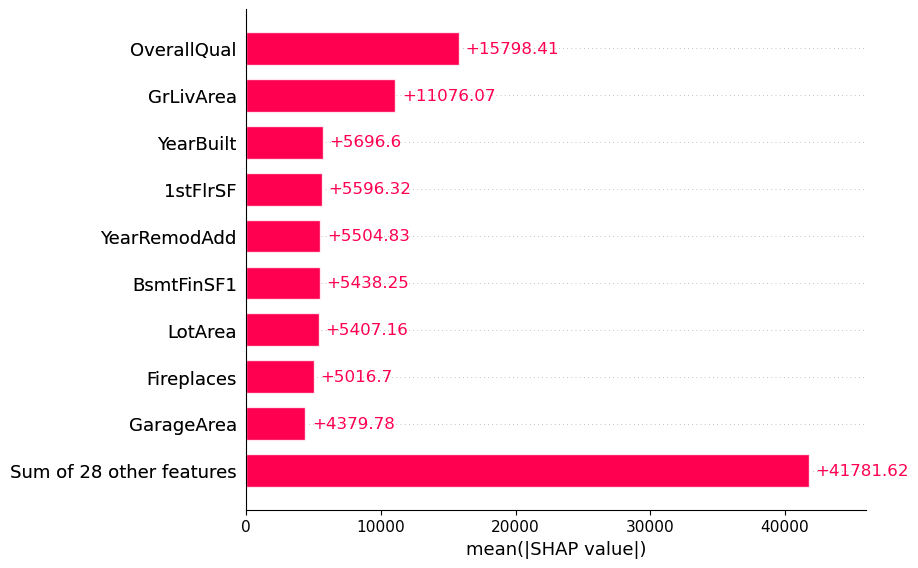

In [7]:
shap.plots.bar(shap_values, max_display=10)

### Beeswarm plot — direction + spread

Every dot is one row's SHAP value for that feature. Color = the feature's value (red = high, blue = low).

Reading it:
- Features are ordered by global importance (top = most important)
- Dots to the **right** pushed the prediction *up*; dots to the **left** pushed it *down*
- If red dots cluster on the right and blue on the left, the feature has a **positive** relationship with the target (and vice versa)
- Wide spread = the feature matters a lot in some rows, little in others

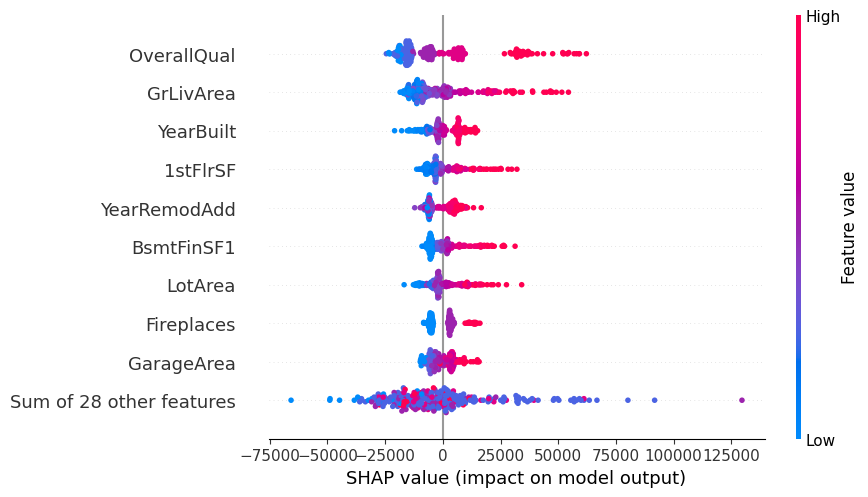

In [10]:
shap.plots.beeswarm(shap_values, max_display=10)

### Waterfall plot — one prediction, decomposed

Pick a single test row. The waterfall starts at the base value (average prediction) and shows how each feature pushes the prediction up (red) or down (blue) until it reaches the final prediction for this row.

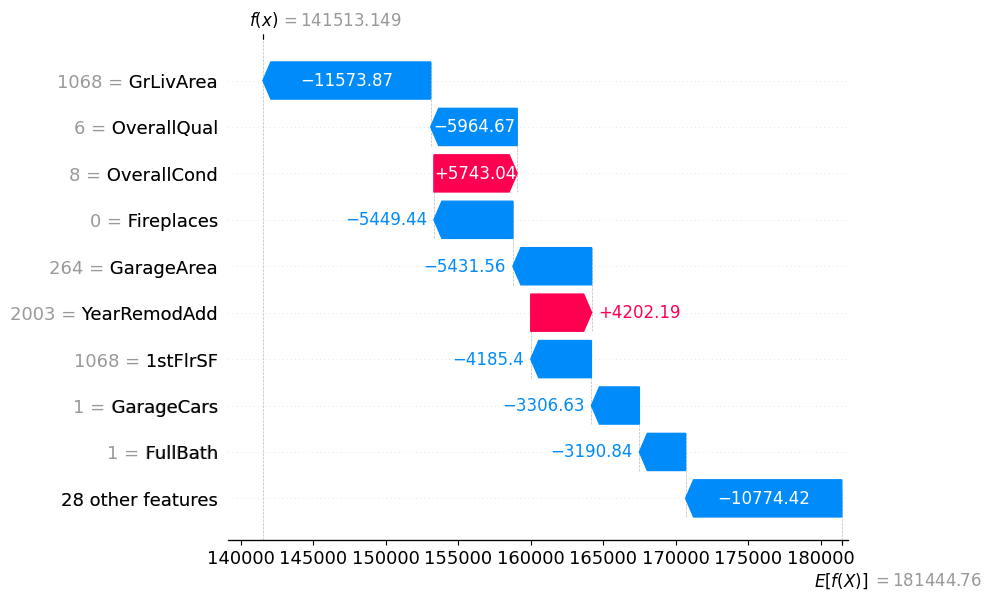

In [11]:
shap.plots.waterfall(shap_values[0], max_display=10)

### Additivity check

SHAP's defining property: **the base value plus all SHAP values equals the model's prediction**, for every row.

In [12]:
row = 0
reconstructed = shap_values.base_values[row] + shap_values.values[row].sum()
actual        = catboost_model.predict(X_test.iloc[[row]])[0]

print(f"base + sum(phi_i):  {reconstructed:.2f}")
print(f"model prediction:   {actual:.2f}")
print(f"match: {np.isclose(reconstructed, actual)}")

base + sum(phi_i):  141513.15
model prediction:   141513.15
match: True


### Dependence (scatter) plot — zoom in on one feature

Pick the top feature and plot SHAP value vs feature value. SHAP will auto-color by the feature it most interacts with.

Top feature: OverallQual
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Int

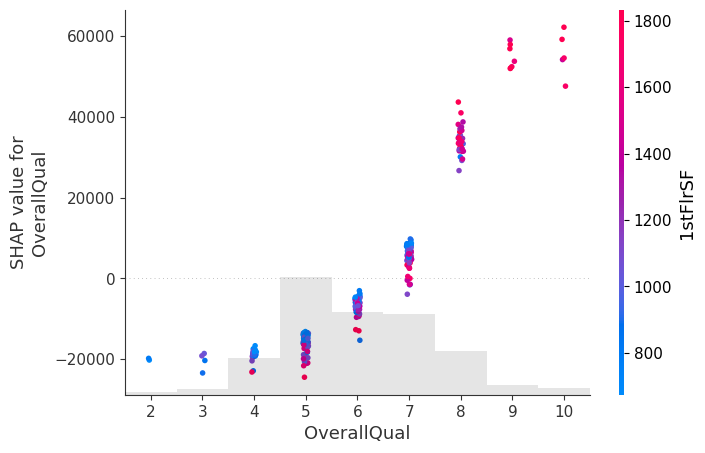

In [13]:
top_feature = X_test.columns[np.argmax(np.abs(shap_values.values).mean(axis=0))]
print(f"Top feature: {top_feature}")

shap.plots.scatter(shap_values[:, top_feature], color=shap_values)

---
# Part 2: Add categorical features

Now include the string columns. CatBoost handles them natively — no one-hot encoding. Compare which features rise and fall in importance.

**Your turn:**
1. Reload the CSV
2. Select the object (string) columns into `categorical_df`
3. Fill NaNs in those columns with the string `'NA'` (CatBoost doesn't allow NaN in categoricals)
4. Concatenate categorical + numerical columns into `full_df`
5. Save the list of categorical column names as `categorical_features`

In [15]:
df = pd.read_csv("../Data/train.csv")
categorical_df = df.select_dtypes(include=['object']).copy()
numerical_df   = df.select_dtypes(include=['number'])

categorical_df = categorical_df.fillna('NA')

categorical_features = categorical_df.columns.tolist()
full_df = pd.concat([categorical_df, numerical_df], axis=1)

print(f"{len(categorical_features)} categorical features")

43 categorical features


**Your turn:** split `full_df` into `X` (features) and `y` (`SalePrice`), then 80/20 train/test split with `random_state=42`.

In [16]:
X = full_df.drop(columns=['SalePrice'])
y = full_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Your turn:** fit a new `CatBoostRegressor` (same hyperparams as before: `iterations=1000`, `learning_rate=0.1`, `depth=6`, `verbose=200`). **This time pass `cat_features=categorical_features` to `.fit()`** so CatBoost handles them natively.

In [17]:
catboost_model2 = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=6, verbose=200
)
catboost_model2.fit(X_train, y_train,
                    eval_set=(X_test, y_test),
                    cat_features=categorical_features)

y_pred2 = catboost_model2.predict(X_test)
print(f"Pearson r: {np.corrcoef(y_test, y_pred2)[0, 1]:.4f}")

0:	learn: 72182.6596632	test: 82377.1308432	best: 82377.1308432 (0)	total: 17.6ms	remaining: 17.6s
200:	learn: 11780.9827710	test: 25887.6359189	best: 25874.9486234 (197)	total: 1.75s	remaining: 6.97s
400:	learn: 7916.0581708	test: 25536.3671255	best: 25522.5705186 (397)	total: 3.52s	remaining: 5.25s
600:	learn: 5842.7157361	test: 25565.7213127	best: 25484.4424441 (470)	total: 5.29s	remaining: 3.51s
800:	learn: 4504.0141400	test: 25548.1621751	best: 25484.4424441 (470)	total: 7.09s	remaining: 1.76s
999:	learn: 3472.9254371	test: 25513.2078572	best: 25484.4424441 (470)	total: 8.86s	remaining: 0us

bestTest = 25484.44244
bestIteration = 470

Shrink model to first 471 iterations.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Pearson r: 0.9585


## SHAP on the full model

Now that you've seen the SHAP API in Part 1, implement the same three plots for `catboost_model2`.

**Your turn:**
1. Create a `TreeExplainer` for `catboost_model2` and compute SHAP values on `X_test`
2. Show the bar plot with `max_display=10`
3. Show the beeswarm plot with `max_display=10`
4. Show a waterfall plot for a single row (row 36 is interesting — try others too)

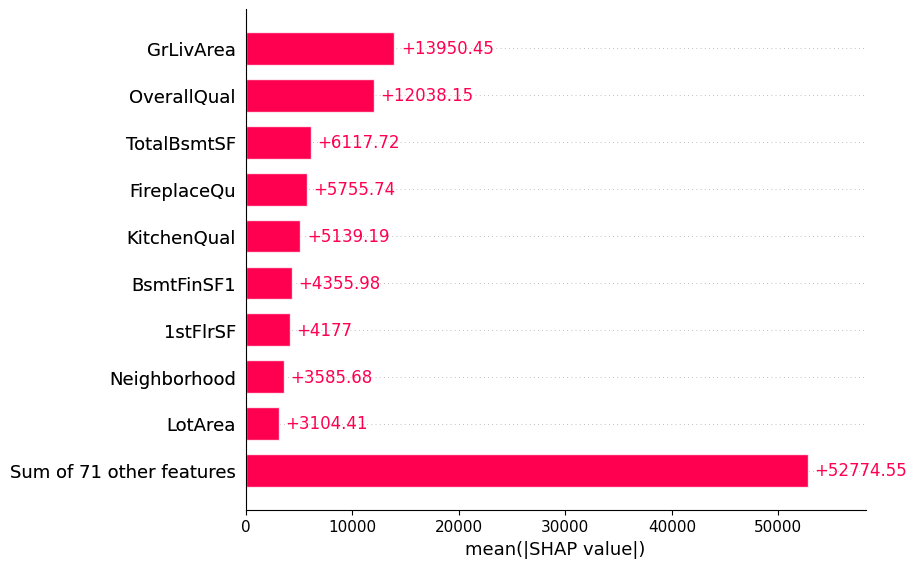

In [18]:
explainer2 = shap.TreeExplainer(catboost_model2)
shap_values2 = explainer2(X_test)

shap.plots.bar(shap_values2, max_display=10)

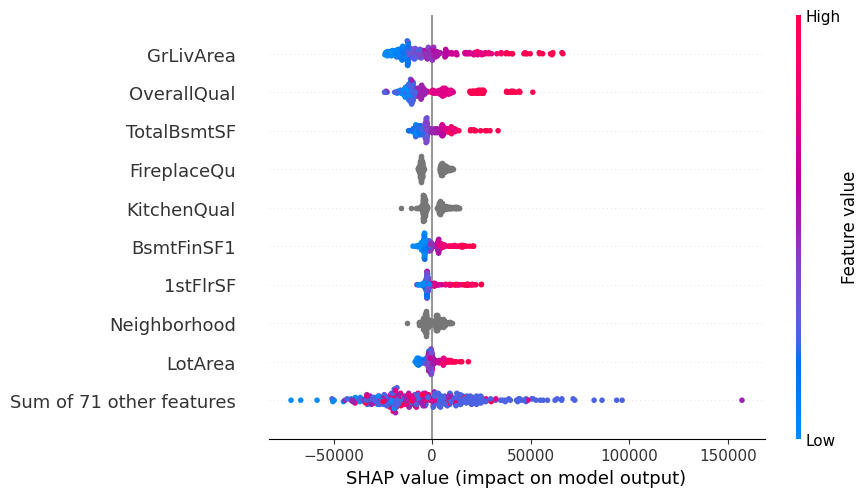

In [19]:
shap.plots.beeswarm(shap_values2, max_display=10)

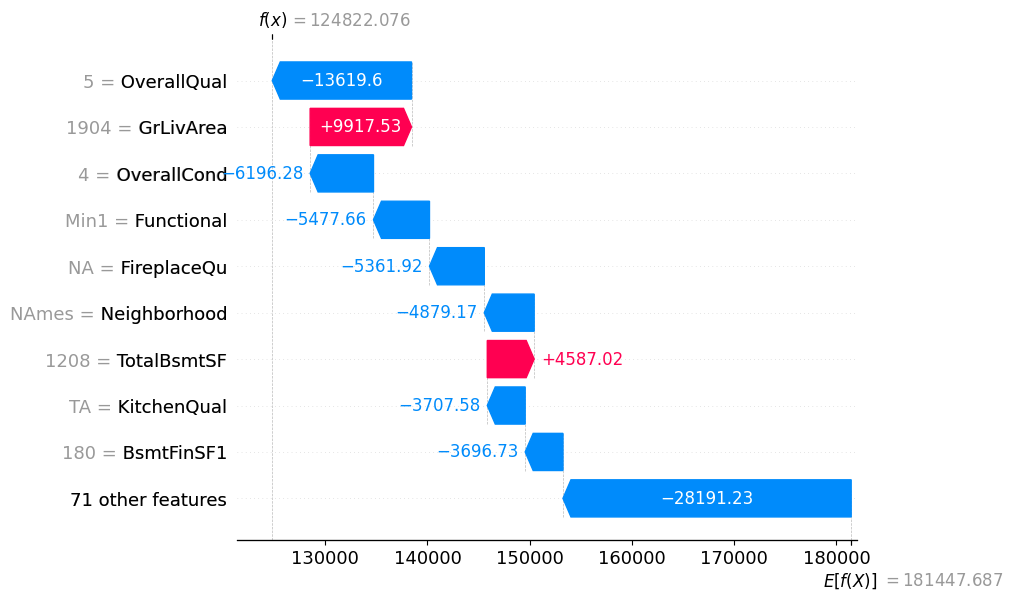

In [20]:
shap.plots.waterfall(shap_values2[36], max_display=10)

---
# Part 3: Your turn

1. Pick a different test row and make a waterfall plot for it. Can you tell a **story** about why the model predicted what it did?
2. Try `shap.plots.scatter(shap_values2[:, 'OverallQual'])` and `shap.plots.scatter(shap_values2[:, 'GrLivArea'])`. How does the SHAP value change with the feature value?
3. Compare the top features between Part 1 (numerical only) and Part 2 (numerical + categorical). Did any new categorical features crack the top 10?

In [ ]:
# 1. Another waterfall
shap.plots.waterfall(shap_values2[7], max_display=10)

In [ ]:
# 2. Scatter plots for two key features
shap.plots.scatter(shap_values2[:, 'OverallQual'], color=shap_values2)

In [ ]:
shap.plots.scatter(shap_values2[:, 'GrLivArea'], color=shap_values2)

*Observations:* `OverallQual` shows a strong monotonic relationship — low quality drops the prediction by tens of thousands of dollars, top quality adds that much and more. `GrLivArea` rises roughly linearly with SHAP value, but with interactions: at the same area, higher-quality houses get a bigger SHAP boost (coloring picks this up automatically).

---
# Part 4: Try it with your own data

Now apply the full pipeline to a dataset **you** care about — a problem set, a project, a Kaggle CSV, or a file from your computer.

**Your checklist:**
1. Load into a `pandas.DataFrame`
2. Identify the **target** column (must be continuous for regression)
3. Identify **categorical** columns (object / category dtype, or numeric codes that are really categorical)
4. Fill NaNs in categorical columns with a placeholder string
5. Fit a `CatBoostRegressor` with `cat_features=...`
6. Build a `TreeExplainer` and show the bar, beeswarm, and a waterfall plot

The demo below uses seaborn's `diamonds` dataset (price prediction with `cut`, `color`, `clarity` as categoricals). **Replace it with your own data.**

## 4.1 Load and inspect

In [ ]:
# -------- REPLACE THIS BLOCK --------
byod = sns.load_dataset('diamonds')
target_col = 'price'
# -------- END REPLACE --------

print("Shape:", byod.shape)
print("\nDtypes:")
print(byod.dtypes)
byod.head()

## 4.2 Prepare features

**Your turn:**
1. Split into `X_byod` (features) and `y_byod` (target)
2. Auto-detect categorical columns with `X_byod.select_dtypes(include=['object', 'category']).columns.tolist()`
3. Fill NaN in those columns with `'MISSING'`
4. Do an 80/20 train/test split (`random_state=42`)

In [ ]:
X_byod = byod.drop(columns=[target_col])
y_byod = byod[target_col]

cat_features_byod = X_byod.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical features:", cat_features_byod)

for c in cat_features_byod:
    X_byod[c] = X_byod[c].astype(str).fillna('MISSING')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_byod, y_byod, test_size=0.2, random_state=42
)
print("Train:", X_tr.shape, "Test:", X_te.shape)

## 4.3 Fit CatBoost

**Your turn:** fit a `CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=200)` with `cat_features=cat_features_byod`. Print Pearson r on the test set.

In [ ]:
model_byod = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=6, verbose=200
)
model_byod.fit(X_tr, y_tr,
               eval_set=(X_te, y_te),
               cat_features=cat_features_byod)

y_pred_byod = model_byod.predict(X_te)
print(f"Pearson r: {np.corrcoef(y_te, y_pred_byod)[0, 1]:.4f}")

## 4.4 Explain with SHAP

**Your turn:** build a `TreeExplainer` on `model_byod`, compute SHAP values on `X_te`, and show the **bar plot**, **beeswarm plot**, and a **waterfall** for any single row.

In [ ]:
explainer_byod = shap.TreeExplainer(model_byod)
shap_values_byod = explainer_byod(X_te)

shap.plots.bar(shap_values_byod, max_display=10)

In [ ]:
shap.plots.beeswarm(shap_values_byod, max_display=10)

In [ ]:
shap.plots.waterfall(shap_values_byod[0], max_display=10)

## 4.5 Reflect

- Which features drove predictions on your dataset?
- Were the top SHAP features the ones you *expected* to matter, or were there surprises?
- Look at the beeswarm — did any feature have an unexpected direction (e.g., higher values pushing the prediction *down* when you'd expect the opposite)?

---
# Takeaways

1. **SHAP decomposes each prediction additively** — base value + each feature's contribution sums exactly to the model output. That's what "additive" in SHAP means.
2. **Three plot families cover most of what you need:**
   - `shap.plots.bar` — global ranking (comparable to `get_feature_importance`)
   - `shap.plots.beeswarm` — global ranking + direction + spread
   - `shap.plots.waterfall` — explain a single prediction
3. **Use `TreeExplainer` for tree models** — it's exact and orders of magnitude faster than the generic `shap.Explainer`.
4. **SHAP vs feature importance:** both tell you which features matter globally, but only SHAP tells you *how* they push each individual prediction. That's what makes it usable for case-level explanations (e.g., "why did the model flag this applicant?").